In [ ]:
include("CRD_STA.jl")
using Plots
using Arpack
using SparseArrays

In [217]:
N_cheb = 199
Mr = 0.3
gamma = 1.4
sigma = 0.72
Ro = 1
Co = 0
Tw = 1
R = 100
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T

200×1 Matrix{Float64}:
 1.3888888893355307
 1.3888925463111959
 1.388903512835836
 1.388921775696382
 1.3889473128511325
 1.3889800934001586
 1.3890200775444714
 1.389067216534425
 1.3891214526077647
 1.3891827189185666
 ⋮
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482
 1.3888896535543482

In [ ]:
al = 0.7
be = 0.1
B0 = sparse(B0)
B1 = sparse(B1)H
B0,B1 = TimeMode_BEK(F,G,,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
# val,vec = eigs(B0,-B1,nev=3,sigma=0,tol = 1e-8,maxiter = 10000)
# val
c = eigen(B0,-B1)
val = c.values; 

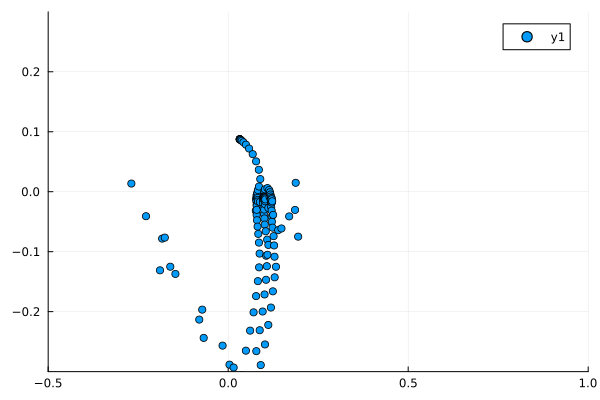

In [225]:
scatter(real(val),imag(val),xlims=[-0.5,1],ylims=[-0.3,0.3])

In [ ]:
function TimeMode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,alpha_given,be,N_cheb,Ro,Co)    
    B0_11 = rho .* I(N_cheb + 1)
    B0_12 = im * be * R * rho .* I(N_cheb + 1)
    B0_13 = R * rho .* (D*rho .* I(N_cheb + 1) + rho .* D)
    B0_14 = im * R * be * G .* I(N_cheb + 1) + 2 * F .* I(N_cheb + 1) + rho .* (D * H) .* I(N_cheb + 1) + rho .* H .* D + alpha_given * (im * R * F .* I(N_cheb + 1))
    B0_15 = zeros(N_cheb + 1, N_cheb + 1)

    B0_21 = im * R * rho .* be .* G .* I(N_cheb + 1) + Ro .* rho .* F .* I(N_cheb + 1) + be^2 .* T .* I(N_cheb + 1) + Ro .* rho.^2 .* H .* D - rho .* D2 + alpha_given .* (im * R * rho .* F .* I(N_cheb + 1)) + alpha_given^2 .* ((lam .+ 2 .* T) .* I(N_cheb + 1))    
    B0_22 = -1 * rho .* (2*Ro * G .+ Co) .* I(N_cheb + 1) + alpha_given * (be * (lam .+ T) .* I(N_cheb + 1))
    B0_23 = R * rho.^2 .* D*F .* I(N_cheb + 1) + alpha_given * (-im * ((rho .* (D*T) + (1 .+ lam .* rho)).* D))
    B0_24 = rho .* (D2 * F) .* I(N_cheb + 1) + alpha_given * (im * R .* I(N_cheb + 1) * (gamma*Ma^2)^(-1) * T .* I(N_cheb + 1))
    B0_25 = -rho .* (D * rho .* D * F + rho .* (D2 * F)) .* I(N_cheb + 1) - rho.^2 .* (D*F) .* D + alpha_given * (im * R .* I(N_cheb + 1) * (gamma*Ma^2)^(-1) * rho .* I(N_cheb + 1))

    B0_31 = rho .* (2 * Ro * G .+ Co) .* I(N_cheb + 1) + alpha_given * (be * (lam + T) .* I(N_cheb + 1))
    B0_32 = im * R * rho .* be .* G .* I(N_cheb + 1) + Ro .* rho .* F .* I(N_cheb + 1) + be^2 .* T .* I(N_cheb + 1) + Ro .* rho.^2 .* H .* D - rho .* D2 + alpha_given .* (im * R * rho .* F .* I(N_cheb + 1)) + alpha_given^2 .* ((lam .+ 2 .* T) .* I(N_cheb + 1))    
    B0_33 = R * rho.^2 .* (D*G) .* I(N_cheb + 1) - im * be * (rho .* (D*T) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D)
    B0_34 = F .* (2 * Ro * G .+ Co) .* I(N_cheb + 1) + Ro * rho .* H .* (D*G) .* I(N_cheb + 1) + im * be * R * (gamma*Ma^2)^(-1) * T .* I(N_cheb + 1)
    B0_35 = -rho .* (D * rho .* D * G + rho .* (D2 * G)) .* I(N_cheb + 1) - rho.^2 .* (D*G) .* D + im * be * R * (gamma*Ma^2)^(-1) * rho .* I(N_cheb + 1)

    B0_41 = zeros(N_cheb + 1, N_cheb + 1) + alpha_given * (-im * (rho .* (D*lam) .* I(N_cheb + 1) + (1 .+ lam .* rho) .* D))
    B0_42 = -im * be * (rho .* (D*lam) + (1 .+ lam .* rho)).*D
    B0_43 = im * R * rho .* be .* G .* I(N_cheb + 1) + Ro * rho.^2 .* ((D * H) .* I(N_cheb + 1) + H .* D) - rho .* (2 .+ lam .* rho) .* D2 + be^2 * T .* I(N_cheb + 1) + alpha_given * (im * R * rho .* F .* I(N_cheb + 1)) + alpha_given^2 * (T .* I(N_cheb + 1))
    B0_44 = (gamma*Ma^2)^(-1) * R * rho .* ((D*T) .* I(N_cheb + 1) + T .* D)
    B0_45 = -im * rho .* (be .* (D*G)) .* I(N_cheb + 1) + (gamma*Ma^2)^(-1) * R * rho .* (D*rho.* I(N_cheb + 1) + rho .* D) + alpha_given * (-im * rho .* ( (D*F)) .* I(N_cheb + 1))

    B0_51 = -2 * (gamma - 1) * Ma^2 * rho .* (D*F) .* D
    B0_52 = -2 * (gamma - 1) * Ma^2 * rho .* (D*G) .* D
    B0_53 = -2 * im * (gamma - 1) * Ma^2 * (be * (D*G)) .* I(N_cheb + 1) + R * rho.^2 .* (D*T) .* I(N_cheb + 1) + alpha_given * (-2 * im * (gamma - 1) * Ma^2 * D * F .* I(N_cheb + 1))
    B0_54 = rho .* H .* (D*T) .* I(N_cheb + 1) - ((gamma - 1) * (gamma)^(-1) * ((im * R * be * G .* T .* I(N_cheb + 1)) + rho .* H .* D*T .* I(N_cheb + 1) + rho .* H .* T .* D)) + alpha_given * (-(gamma - 1) * (gamma)^(-1) * im * R * F .* T .* I(N_cheb + 1))
    B0_55 = (im * R * rho .* be .* G .* I(N_cheb + 1)) + 
        (be^2 * kappa .* I(N_cheb + 1)) + 
        (rho.^2 .* (H .* D - kappa .* D2)) + 
        ((1/sigma) * (-rho .* (((D*rho) .* (D*T) .* I(N_cheb + 1)) + 
                               (rho .* (D2 * T) .* I(N_cheb + 1)) - 
                               (rho .* (D*T) .* D)))) + 
        (-(gamma - 1) * Ma^2 * rho.^2 .* ((D*F).^2 + (D*G).^2) .* I(N_cheb + 1)) - 
        ((gamma - 1) * (gamma)^(-1) * ((im * R * be * G .* rho .* I(N_cheb + 1)) + 
                                       (rho .* H .* (D*rho) .* I(N_cheb + 1)) + 
                                       (rho .* H .* rho .* D))) + 
        (alpha_given .* (im * R * rho .* F .* I(N_cheb + 1) - 
                       (gamma - 1) * (gamma)^(-1) * im * R * F .* rho .* I(N_cheb + 1))) + 
        (alpha_given^2 .* (kappa .* I(N_cheb + 1)))

    B1_11 = zeros(N_cheb + 1, N_cheb + 1)
    B1_12 = zeros(N_cheb + 1, N_cheb + 1)
    B1_13 = zeros(N_cheb + 1, N_cheb + 1)
    B1_14 = -im * R .* I(N_cheb + 1) 
    B1_15 = zeros(N_cheb + 1, N_cheb + 1)

    B1_21 = -im * R * rho .* I(N_cheb + 1) 
    B1_22 = zeros(N_cheb + 1, N_cheb + 1)
    B1_23 = zeros(N_cheb + 1, N_cheb + 1)
    B1_24 = zeros(N_cheb + 1, N_cheb + 1)
    B1_25 = zeros(N_cheb + 1, N_cheb + 1)

    B1_31 = zeros(N_cheb + 1, N_cheb + 1)
    B1_32 = -im * R * rho .* I(N_cheb + 1) 
    B1_33 = zeros(N_cheb + 1, N_cheb + 1)
    B1_34 = zeros(N_cheb + 1, N_cheb + 1)
    B1_35 = zeros(N_cheb + 1, N_cheb + 1)

    B1_41 = zeros(N_cheb + 1, N_cheb + 1)
    B1_42 = zeros(N_cheb + 1, N_cheb + 1)
    B1_43 = -im * R * rho .* I(N_cheb + 1) 
    B1_44 = zeros(N_cheb + 1, N_cheb + 1)
    B1_45 = zeros(N_cheb + 1, N_cheb + 1)

    B1_51 = zeros(N_cheb + 1, N_cheb + 1)
    B1_52 = zeros(N_cheb + 1, N_cheb + 1)
    B1_53 = zeros(N_cheb + 1, N_cheb + 1)
    B1_54 = (gamma - 1) * (gamma)^(-1) * im * R * T .* I(N_cheb + 1) 
    B1_55 = -im * R * rho .* I(N_cheb + 1) + (gamma - 1) * (gamma)^(-1) * im * R * rho .* I(N_cheb + 1) 

    # 组装完整矩阵
    B0 = [B0_11 B0_12 B0_13 B0_14 B0_15;
          B0_21 B0_22 B0_23 B0_24 B0_25;
          B0_31 B0_32 B0_33 B0_34 B0_35;
          B0_41 B0_42 B0_43 B0_44 B0_45;
          B0_51 B0_52 B0_53 B0_54 B0_55]

    B1 = [B1_11 B1_12 B1_13 B1_14 B1_15;
          B1_21 B1_22 B1_23 B1_24 B1_25;
          B1_31 B1_32 B1_33 B1_34 B1_35;
          B1_41 B1_42 B1_43 B1_44 B1_45;
          B1_51 B1_52 B1_53 B1_54 B1_55]
    B0 = B0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    B1 = B1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    return B0, B1
end

TimeMode_BEK (generic function with 1 method)